In [4]:
# =====================
# Test Environment Setup
# =====================


# Model will download automatically into Ultralytic cache
# model = YOLO("yolov8n.pt") 

In [5]:
# ===================
# Test the Setup Model
# ===================
# import numpy as np

# img = np.zeros((640, 640, 3), dtype=np.uint8)
# results = model(img)
# results

In [20]:
%reload_ext autoreload
%autoreload 2

In [6]:
from ultralytics import YOLO

class YOLODetector:
    def __init__(self, model_path: str):
        self.model = YOLO(model_path)

    def predict(self, frame):
        results = self.model.predict(
            frame,
            verbose=False,
            conf=0.35
        )
        return results[0]

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

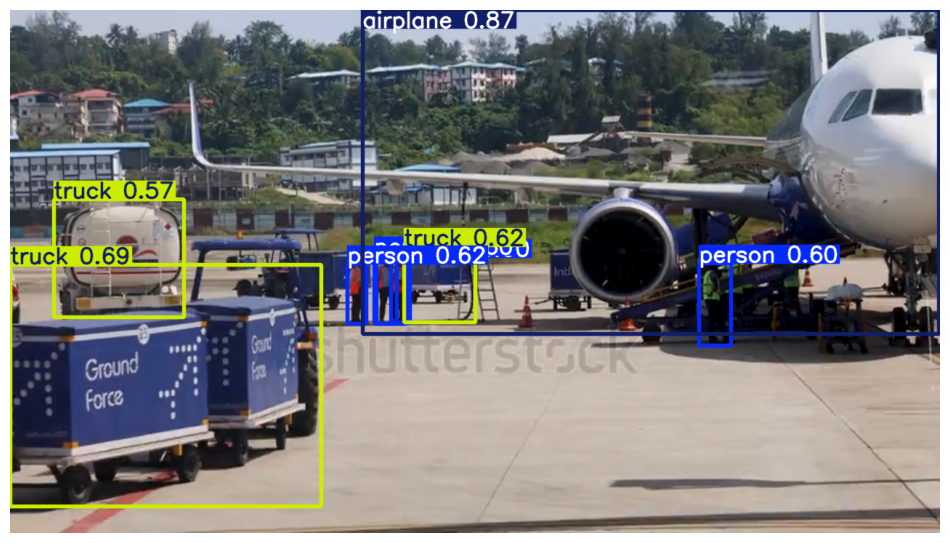

In [7]:
# =======================
# Test Inference Scripts
# =======================
import sys
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.getcwd()).parent
# Connect to custom-defined modules
sys.path.append(str(PROJECT_ROOT))

from airport_ai.streams.camera import AsyncCamera
# from airport_ai.inference.detector import YOLODetector
from airport_ai.inference.parser import DetectionParser
from airport_ai.config.settings import *

camera = AsyncCamera(
    source=VIDEO_SOURCE,
    width=FRAME_WIDTH,
    height=FRAME_HEIGHT,
    queue_size=FRAME_QUEUE_SIZE,
).start()

detector = YOLODetector(str(PROJECT_ROOT/"models/yolov8n.pt"))
detector_parser = DetectionParser()

""" Window Not Opening"""
# while True:
#     frame = camera.read()
#     result = detector.predict(frame)
#     detections = parser.parse(result)
#     annotated = result.plot()
#     cv2.imshow("YOLO Detection", annotated)
#     print("-"*40)
#     for detection in detections:
#         print(detection)
#     if cv2.waitKey(1) == ord("q"):
#         break
# camera.stop()
# cv2.destroyAllWindows()

frame = camera.read()
detector_result = detector.predict(frame)
detections = detector_parser.parse(detector_result)
detector_annotated = detector_result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(detector_annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")


In [8]:
for detection in detections:
    print(detection)

Detection(class_id=4, class_name='airplane', confidence=0.8699690699577332, x1=485.0057373046875, y1=1.15252685546875, x2=1278.0826416015625, y2=446.7763366699219, center_x=881.544189453125, center_y=223.9644317626953, width=793.076904296875, height=445.6238098144531)
Detection(class_id=7, class_name='truck', confidence=0.6927333474159241, x1=0.4136962890625, y1=351.25439453125, x2=428.1903381347656, y2=683.166259765625, center_x=214.30201721191406, center_y=517.2103271484375, width=427.7766418457031, height=331.911865234375)
Detection(class_id=0, class_name='person', confidence=0.6217795610427856, x1=464.9528503417969, y1=350.4241943359375, x2=490.3046569824219, y2=432.3675537109375, center_x=477.6287536621094, center_y=391.3958740234375, width=25.351806640625, height=81.943359375)
Detection(class_id=7, class_name='truck', confidence=0.6197807788848877, x1=542.2836303710938, y1=326.98333740234375, x2=640.8037719726562, y2=430.48687744140625, center_x=591.543701171875, center_y=378.735

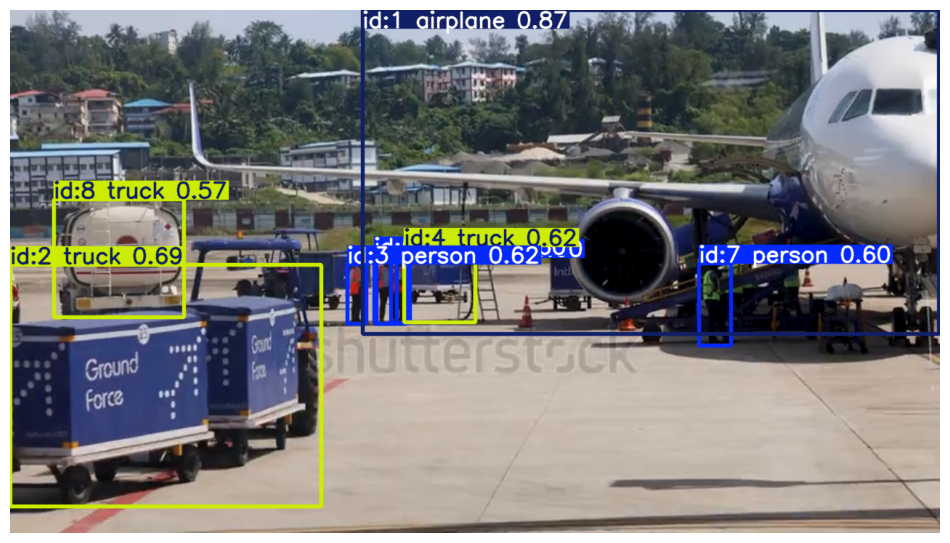

In [16]:
# ==========================
# Test Object Tracking
# ==========================
from airport_ai.tracking.tracker import YOLOTracker
from airport_ai.tracking.parser import TrackingParser

tracker = YOLOTracker(str(PROJECT_ROOT/"models/yolov8n.pt"))
tracker_parser = TrackingParser()

tracker_result = tracker.track(frame)
tracked_objects = tracker_parser.parse(tracker_result)
tracker_annotated = tracker_result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(tracker_annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [17]:
for obj in tracked_objects:
    print(obj)

TrackedObject(track_id=1, class_id=4, class_name='airplane', confidence=0.8699690699577332, x1=485.0057373046875, y1=1.15252685546875, x2=1278.0826416015625, y2=446.7763366699219, center_x=881.544189453125, center_y=223.9644317626953, width=793.076904296875, height=445.6238098144531)
TrackedObject(track_id=2, class_id=7, class_name='truck', confidence=0.6927333474159241, x1=0.4136962890625, y1=351.25439453125, x2=428.1903381347656, y2=683.166259765625, center_x=214.30201721191406, center_y=517.2103271484375, width=427.7766418457031, height=331.911865234375)
TrackedObject(track_id=3, class_id=0, class_name='person', confidence=0.6217795610427856, x1=464.9528503417969, y1=350.4241943359375, x2=490.3046569824219, y2=432.3675537109375, center_x=477.6287536621094, center_y=391.3958740234375, width=25.351806640625, height=81.943359375)
TrackedObject(track_id=4, class_id=7, class_name='truck', confidence=0.6197807788848877, x1=542.2836303710938, y1=326.98333740234375, x2=640.8037719726562, y2

In [18]:
# ==============================
# Turnaround Pipeline
# ==============================
# 1. Aircraft Selection
from airport_ai.decision.turnaround.aircraft import AircraftSelector

selector = AircraftSelector()
aircraft = selector.select(tracked_objects)

print(aircraft)

TrackedObject(track_id=1, class_id=4, class_name='airplane', confidence=0.8699690699577332, x1=485.0057373046875, y1=1.15252685546875, x2=1278.0826416015625, y2=446.7763366699219, center_x=881.544189453125, center_y=223.9644317626953, width=793.076904296875, height=445.6238098144531)


In [22]:
from airport_ai.config.settings import *

In [28]:
# 2. Safety Zone & Evaluator
from airport_ai.decision.turnaround.zone import SafetyZoneGenerator
from airport_ai.decision.turnaround.evaluator import TurnaroundEvaluator

if aircraft is not None:
    generator = SafetyZoneGenerator(
        margin_x=ZONE_MARGIN_X,
        margin_y=ZONE_MARGIN_Y
    )
    safety_zone = generator.generate(aircraft)
    evaluator = TurnaroundEvaluator()
    events = evaluator.evaluate(tracked_objects, safety_zone)

for event in events:
    print(event.event_type)
    print(event.message)


Safety Zone Violation
Person 3 entered aircraft safety zone.
Vehicle Zone Violation
Vehicle 4 entered aircraft safety zone.
Safety Zone Violation
Person 5 entered aircraft safety zone.
Safety Zone Violation
Person 6 entered aircraft safety zone.
Safety Zone Violation
Person 7 entered aircraft safety zone.
Safety Zone Violation
Person 9 entered aircraft safety zone.


In [24]:
# 3. Test Visualizer
from airport_ai.decision.turnaround.visualization import TurnaroundVisualizer
visualizer = TurnaroundVisualizer()
frame = visualizer.draw_zone(frame, safety_zone)